# SkinGuide AI: Exploratory Data Analysis (EDA)

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [7]:
df = pd.read_csv(r"E:\SkinGuide\data\raw\datasheet.csv")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Dataset Information ---")
print(df.info())

Dataset Shape: 19886 rows, 6 columns

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19886 entries, 0 to 19885
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   brand        19886 non-null  object
 1   name         19886 non-null  object
 2   type         19871 non-null  object
 3   country      19886 non-null  object
 4   ingridients  19567 non-null  object
 5   afterUse     18365 non-null  object
dtypes: object(6)
memory usage: 932.3+ KB
None


In [8]:
print("--- Missing Values Count ---")
print(df.isnull().sum())

--- Missing Values Count ---
brand             0
name              0
type             15
country           0
ingridients     319
afterUse       1521
dtype: int64


In [9]:
print("-------Drop missing values by column 'ingridients'--------")
print(f"Shape of dataset (Before) :{df.shape}")
df.dropna(subset=['ingridients'], inplace=True)
print(f"Shape of dataset (After) :{df.shape}")

-------Drop missing values by column 'ingridients'--------
Shape of dataset (Before) :(19886, 6)
Shape of dataset (After) :(19567, 6)


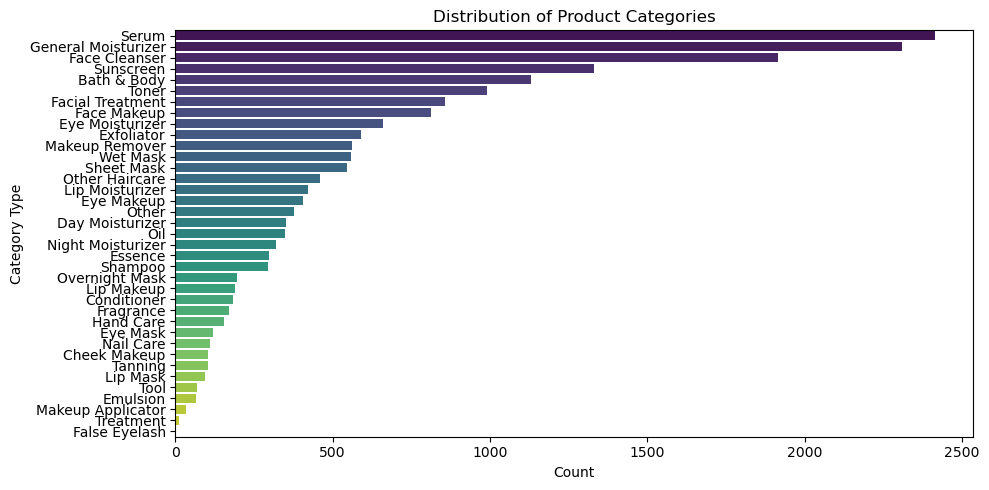

In [10]:
plt.figure(figsize=(10, 5))
type_counts = df['type'].value_counts()
sns.barplot(x=type_counts.values, y=type_counts.index, hue=type_counts.index, palette="viridis", legend=False)
plt.title("Distribution of Product Categories")
plt.xlabel("Count")
plt.ylabel("Category Type")
plt.tight_layout()
plt.show()

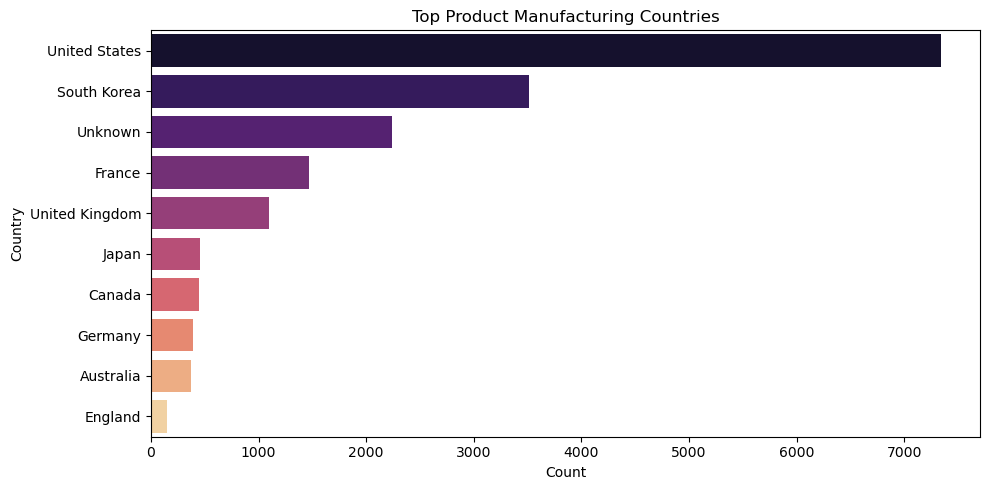

In [11]:
plt.figure(figsize=(10, 5))
country_counts = df['country'].value_counts().head(10)
sns.barplot(x=country_counts.values, y=country_counts.index, hue=country_counts.index, palette="magma", legend=False)
plt.title("Top Product Manufacturing Countries")
plt.xlabel("Count")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

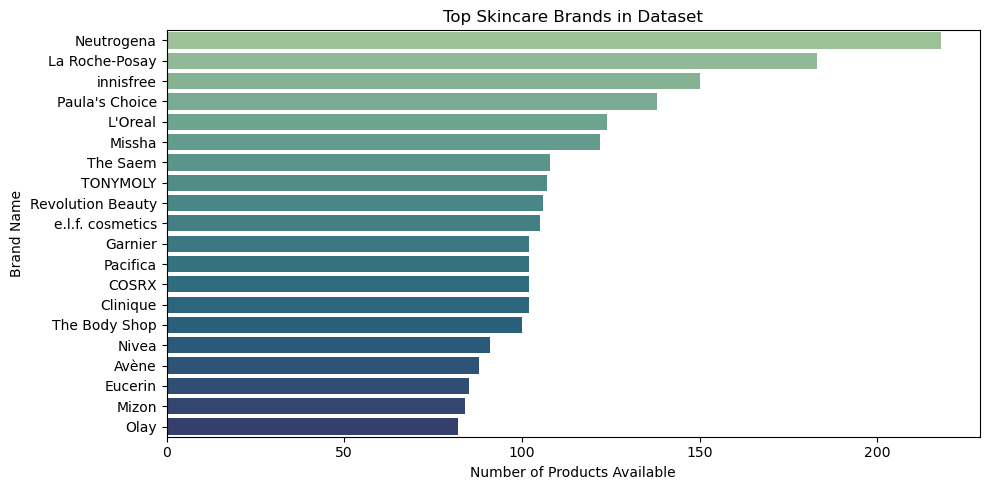

In [6]:
plt.figure(figsize=(10, 5))
brand_counts = df['brand'].value_counts().head(20)
sns.barplot(x=brand_counts.values, y=brand_counts.index, hue=brand_counts.index, palette="crest", legend=False)
plt.title("Top Skincare Brands in Dataset")
plt.xlabel("Number of Products Available")
plt.ylabel("Brand Name")
plt.tight_layout()
plt.show()

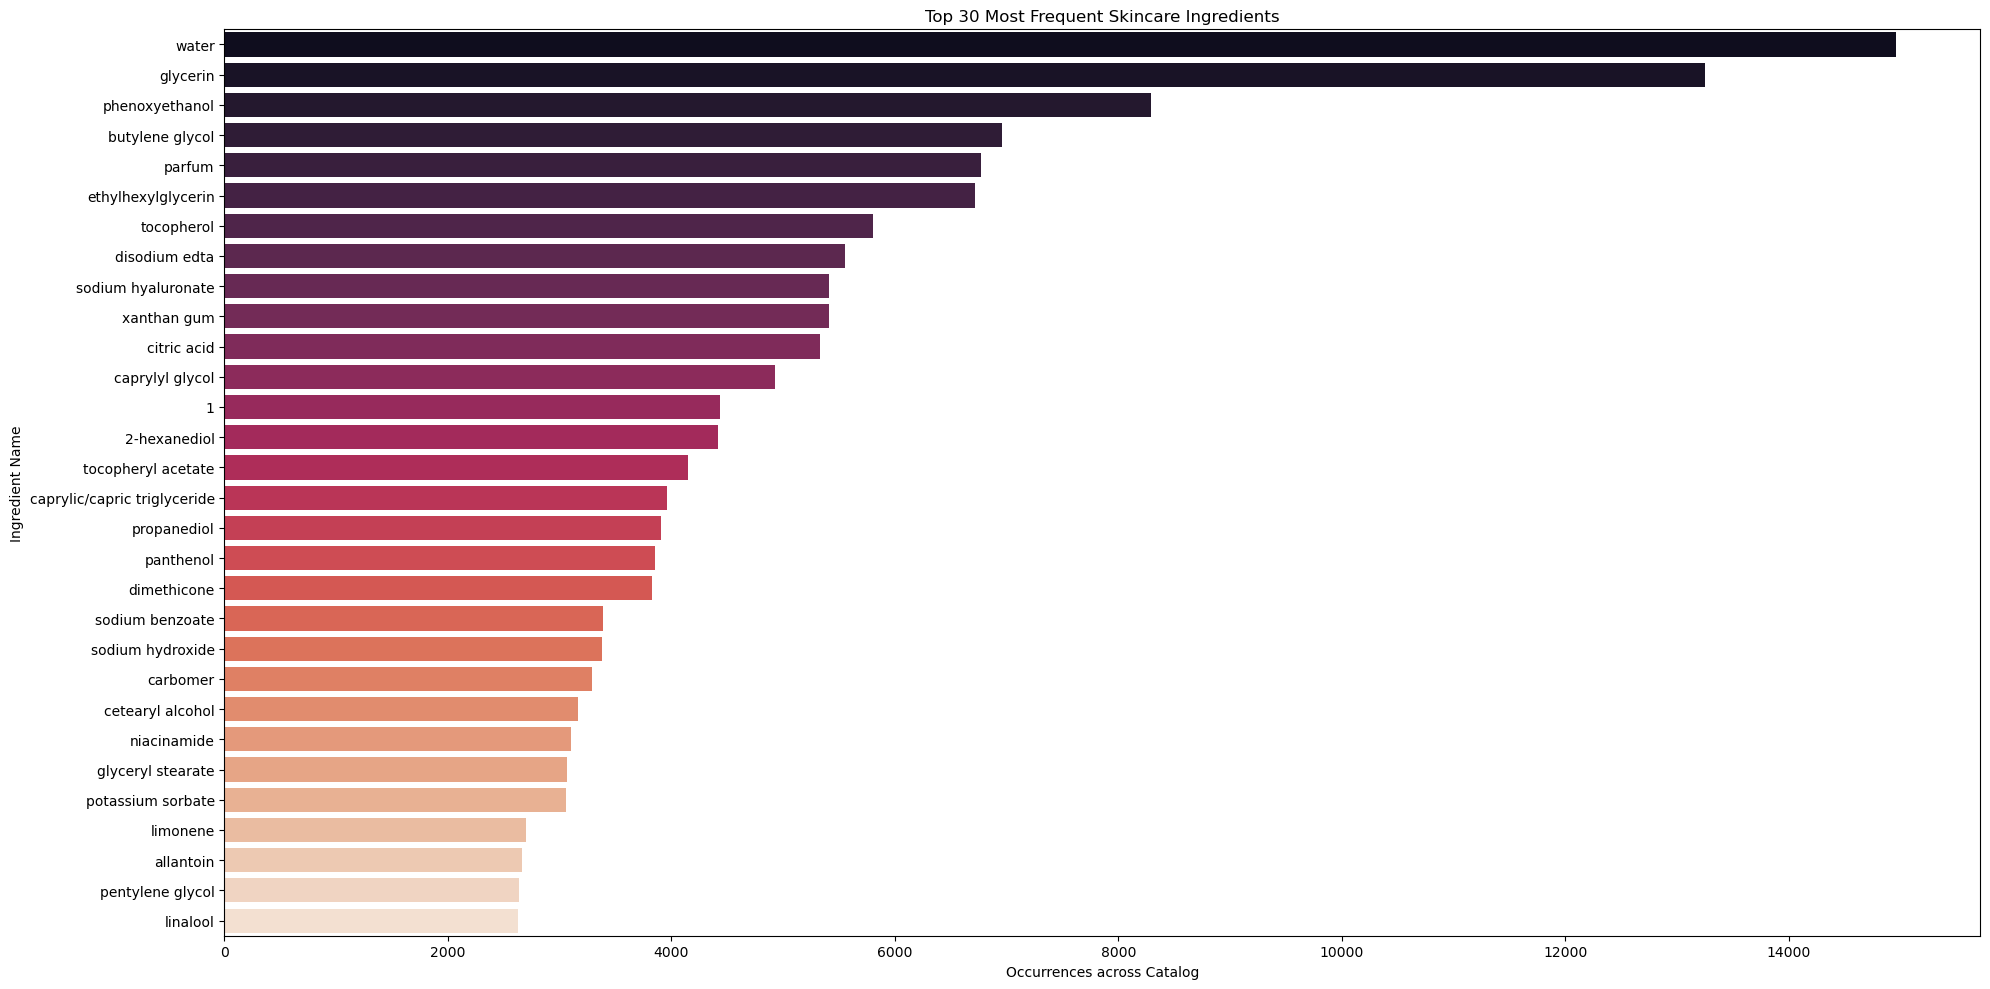

In [12]:
all_ingredients = []

ingredient_col = 'ingridients' if 'ingridients' in df.columns else 'ingredients'

for val in df[ingredient_col].dropna():
    all_ingredients.extend([i.strip().lower() for i in str(val).split(',') if i.strip()])
    
top_ingredients = Counter(all_ingredients).most_common(30)
top_ing_df = pd.DataFrame(top_ingredients, columns=['Ingredient', 'Frequency'])

if not top_ing_df.empty:
    plt.figure(figsize=(20, 10))
    sns.barplot(data=top_ing_df, x='Frequency', y='Ingredient', hue='Ingredient', palette="rocket", legend=False)
    plt.title("Top 30 Most Frequent Skincare Ingredients")
    plt.xlabel("Occurrences across Catalog")
    plt.ylabel("Ingredient Name")
    plt.tight_layout()
    plt.show()

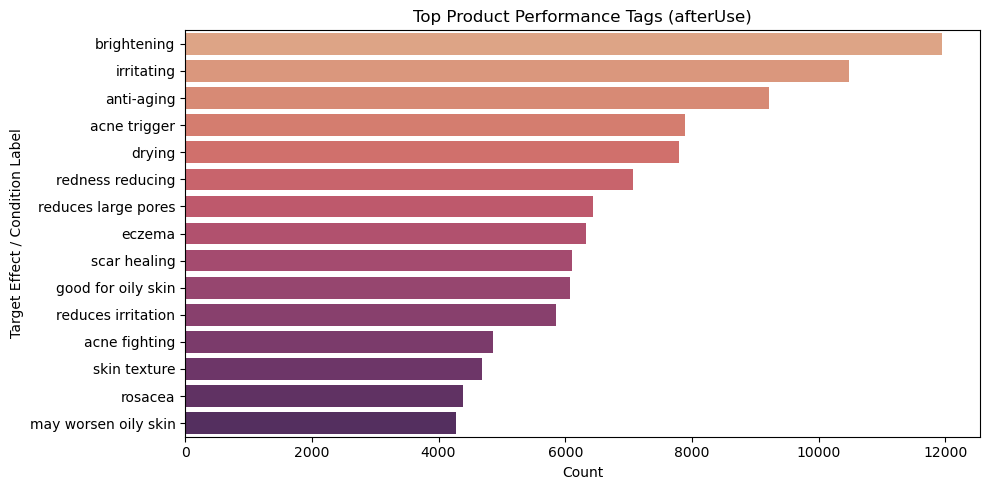

In [14]:
all_tags = []
for val in df['afterUse'].dropna():
    all_tags.extend([t.strip().lower() for t in str(val).split(',') if t.strip()])
    
top_tags = Counter(all_tags).most_common(15)
top_tags_df = pd.DataFrame(top_tags, columns=['Tag / Effect Trigger', 'Frequency'])

plt.figure(figsize=(10, 5))
sns.barplot(data=top_tags_df, x='Frequency', y='Tag / Effect Trigger', hue='Tag / Effect Trigger', palette="flare", legend=False)
plt.title("Top Product Performance Tags (afterUse)")
plt.xlabel("Count")
plt.ylabel("Target Effect / Condition Label")
plt.tight_layout()
plt.show()
